# Perceived Information vs training epoch

Companion to Chapter 8 (`docs/08_perceived_information.md`). For each
checkpoint of the ASCADr MLP, measure Perceived Information (bits) on a
profiling subset and on the attack set. No retraining.

Figure: `outputs/figures/08_pi_curves.png`.

In [1]:
import gc

import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

from feature_emergence.config import MODELS_DIR, OUTPUTS_DIR
from feature_emergence.profiling_and_attack import information, mlp
from feature_emergence.utils import load_dataset, scale_dataset

out = OUTPUTS_DIR / "figures"
out.mkdir(parents=True, exist_ok=True)

2026-09-22 02:40:39.923209: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-22 02:40:40.001361: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-22 02:40:40.001404: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-22 02:40:40.003043: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-22 02:40:40.011894: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-22 02:40:40.013234: I tensorflow/core/platform/cpu_feature_guard.cc:1

2026-09-22 02:40:40.974141: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
N_EPOCHS = 100
# Evaluate every EPOCH_STEP epochs (and always epoch 1 and N_EPOCHS).
EPOCH_STEP = 5
MODEL_NAME = "mlp_ascadr"
NUM_CLASSES = 256
WITHIN_EPOCH_PI_SAMPLE = 10000

In [3]:
dataset = load_dataset("ascad-variable", traces_dim=2000, leakage_model="ID", n_prof=20000)
dataset.x_profiling, dataset.x_attack = scale_dataset(
    dataset.x_profiling, dataset.x_attack, StandardScaler()
)
print(f"profiling: {dataset.x_profiling.shape}  attack: {dataset.x_attack.shape}")

profiling: (20000, 2000)  attack: (10000, 2000)


In [4]:
model = mlp(NUM_CLASSES, dataset.x_profiling.shape[1])

epochs = sorted(
    set([1, N_EPOCHS] + list(range(EPOCH_STEP, N_EPOCHS + 1, EPOCH_STEP)))
)
pi_prof, pi_attack = [], []

for epoch in epochs:
    ckpt = MODELS_DIR / f"{MODEL_NAME}_{epoch:02d}.weights.h5"
    model.load_weights(str(ckpt))
    pred_prof = model.predict(
        dataset.x_profiling[:WITHIN_EPOCH_PI_SAMPLE], verbose=0
    )
    pred_attack = model.predict(dataset.x_attack, verbose=0)
    pi_prof.append(
        information(
            pred_prof,
            dataset.profiling_labels[:WITHIN_EPOCH_PI_SAMPLE],
            NUM_CLASSES,
        )
    )
    pi_attack.append(
        information(pred_attack, dataset.attack_labels, NUM_CLASSES)
    )
    print(
        f"epoch {epoch:3d}: PI(train)={pi_prof[-1]:.4f}  "
        f"PI(attack)={pi_attack[-1]:.4f}"
    )
    gc.collect()

Model: "mlp_softmax"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 input_layer (InputLayer)    [(None, 2000)]            0         


 dense (Dense)               (None, 100)               200100    


...

epoch  80: PI(train)=-6.8728  PI(attack)=-6.8599


epoch  85: PI(train)=-7.1889  PI(attack)=-7.2219


epoch  90: PI(train)=-7.8730  PI(attack)=-7.9643


epoch  95: PI(train)=-8.6627  PI(attack)=-8.7232


epoch 100: PI(train)=-9.2675  PI(attack)=-9.4419


saved: /workspace/outputs/figures/08_pi_curves.png


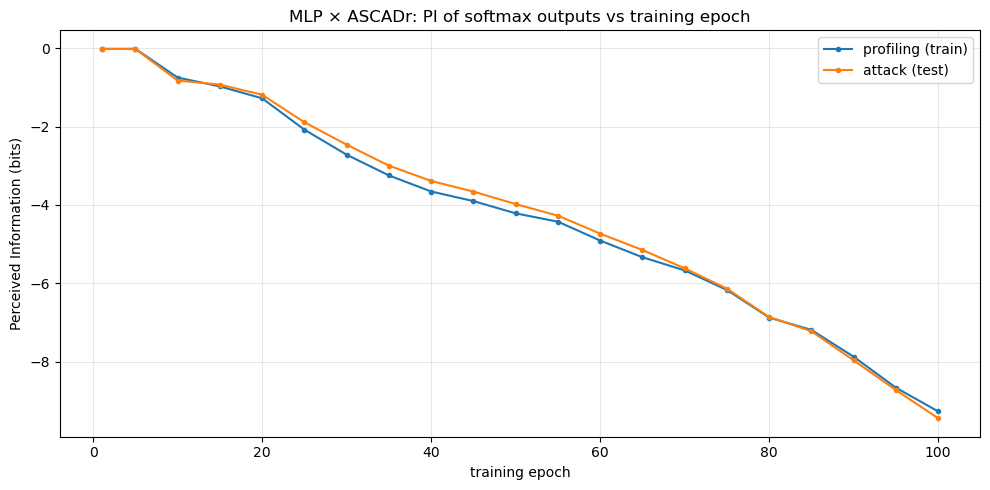

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, pi_prof, marker="o", ms=3, label="profiling (train)")
ax.plot(epochs, pi_attack, marker="o", ms=3, label="attack (test)")
ax.set_xlabel("training epoch")
ax.set_ylabel("Perceived Information (bits)")
ax.set_title("MLP × ASCADr: PI of softmax outputs vs training epoch")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(out / "08_pi_curves.png", dpi=150)
print("saved:", out / "08_pi_curves.png")
plt.show()